# Введение

# Алгоритм K-средних (K-Means)

**K-средних** — это один из самых популярных алгоритмов *обучения без учителя*. Его главная задача — разделить кучу точек на заранее заданное количество групп (кластеров).

### Как он работает «на пальцах»:
1. **Шаг 1:** Мы наугад ставим в пространство несколько точек. Это **центроиды** (центры будущих групп). Их количество $K$ мы выбираем сами.
2. **Шаг 2:** Каждая точка данных «смотрит», к какому центроиду она ближе, и присоединяется к этой группе.
3. **Шаг 3:** Центроиды пересчитываются — они двигаются в самый центр своих новых групп.
4. **Шаги 2 и 3 повторяются**, пока центроиды не перестанут двигаться.

# Создание данных

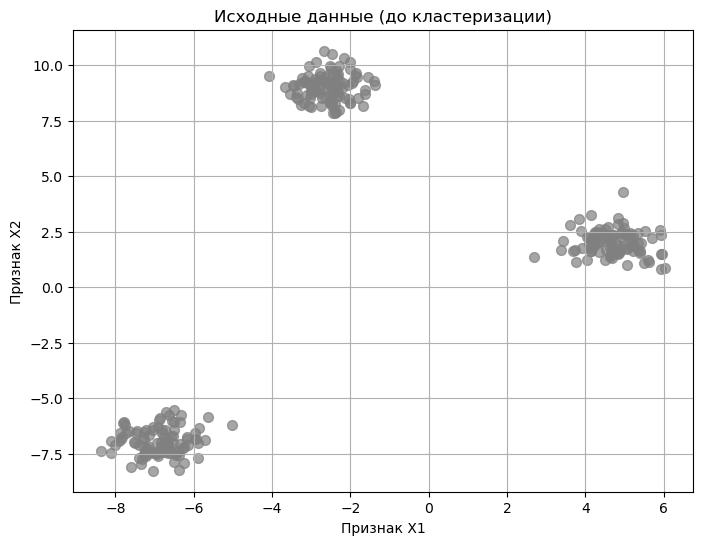

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Создадим искусственные данные (3 отчетливые группы точек)
X, y = make_blobs(
    n_samples=300, centers=3, cluster_std=0.60, random_state=42
)

# Посмотрим на исходные данные (пока они все одного цвета)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, color="gray", alpha=0.7)
plt.title("Исходные данные (до кластеризации)")
plt.xlabel("Признак X1")
plt.ylabel("Признак X2")
plt.grid(True)
plt.show()

# Обучение модели

In [10]:
# 2. Создаем модель K-Means. Мы хотим найти именно 3 кластера.
kmeans = KMeans(n_clusters=3, random_state=42)

# Обучаем алгоритм на наших данных
kmeans.fit(X)

# Получаем предсказанные метки (какая точка к какому кластеру теперь относится)
labels = kmeans.labels_

# Получаем финальные координаты центроидов
centroids = kmeans.cluster_centers_

print("Алгоритм успешно обучен!")

Алгоритм успешно обучен!


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


# Визуализация результата

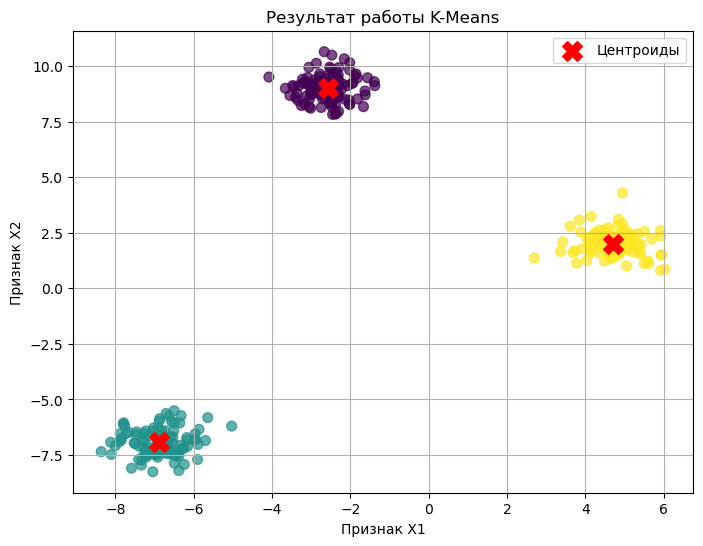

In [11]:
# 3. Визуализируем то, как алгоритм разделил точки
plt.figure(figsize=(8, 6))

# Рисуем точки, раскрашивая их в зависимости от присвоенного кластера
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap="viridis", alpha=0.7)

# Рисуем центроиды (красные крестики)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Центроиды",
)

plt.title("Результат работы K-Means")
plt.xlabel("Признак X1")
plt.ylabel("Признак X2")
plt.legend()
plt.grid(True)
plt.show()

# Итоговое заключение

### Итог:
Посмотрите на график выше. Алгоритм K-means самостоятельно, без подсказок (мы не давали ему правильных ответов `y`), смог:
1. Найти логичные границы между тремя группами точек.
2. Поставить центроиды (красные крестики) ровно в геометрический центр каждого кластера.

**Главный минус алгоритма:** Нужно заранее точно знать число $K$ (количество кластеров). Если бы мы указали `n_clusters=2` или `4`, результат был бы совсем другим.